# Behind the pipeline :-

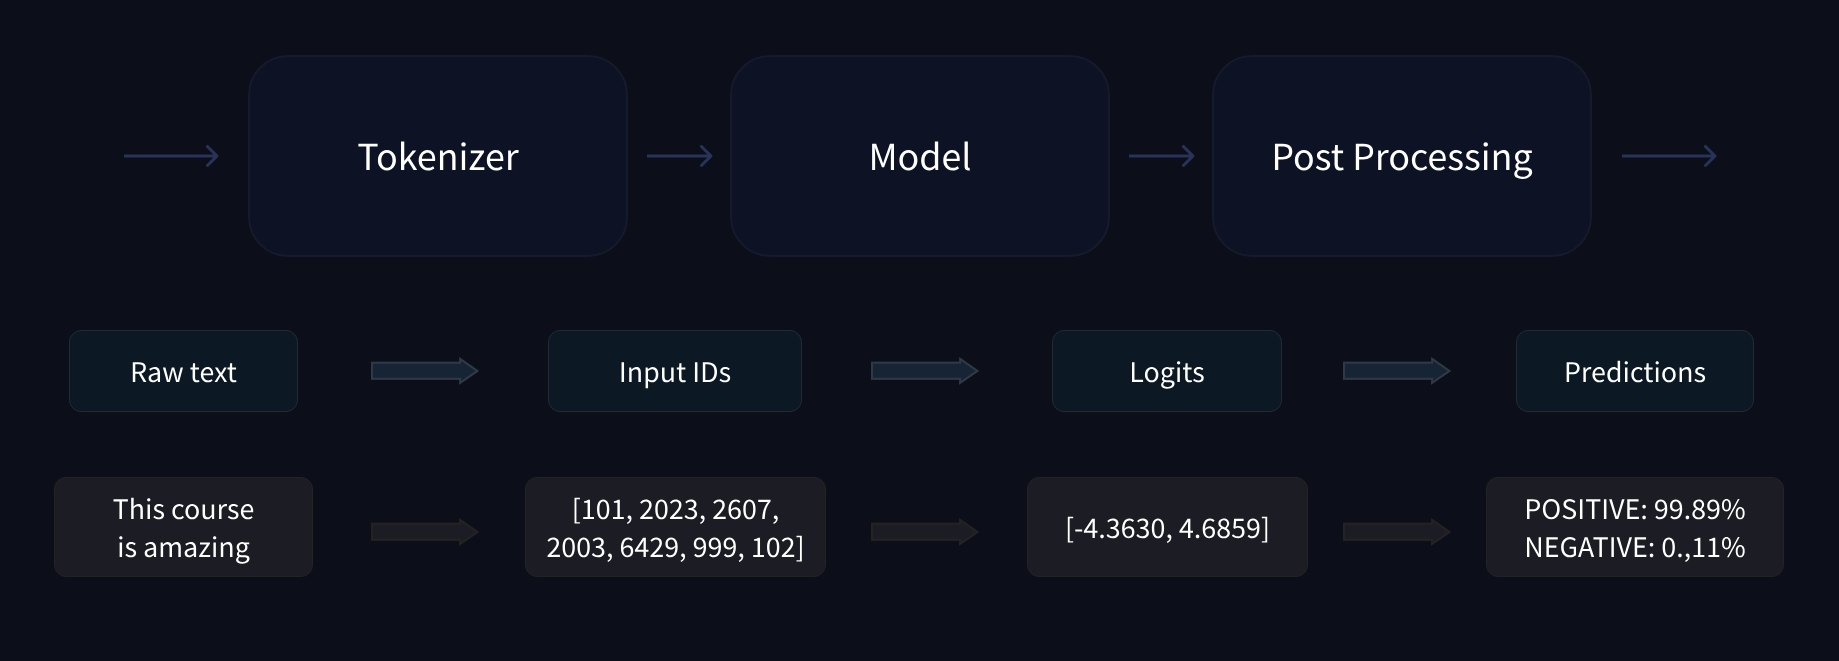

### Preprocessing with a tokenizer :-

Like other neural networks, Transformer models can’t process raw text directly, so the first step of our pipeline is to convert the text inputs into numbers that the model can make sense of. To do this we use a tokenizer, which will be responsible for:

* Splitting the input into words, subwords, or symbols (like punctuation) that are called tokens

* Mapping each token to an integer

* Adding additional inputs that may be useful to the model

All this preprocessing needs to be done in exactly the same way as when the model was pretrained, so we first need to download that information from the Model Hub. To do this, we use the `AutoTokenizer` class and its `from_pretrained()` method. Using the checkpoint name of our model, it will automatically fetch the data associated with the model’s tokenizer and cache it (so it’s only downloaded the first time you run the code below).

Since the default checkpoint of the `sentiment-analysis` pipeline is `distilbert-base-uncased-finetuned-sst-2-english`, we run the following:

#### Checkpoint (actual):

A saved snapshot of a model's weights at a specific point during training. Since training can take days or weeks, checkpoints are saved periodically so that if training crashes you don't lose everything, and also so you can compare the model's performance at different stages of training.

#### Checkpoint (HuggingFace):

On HuggingFace Hub, checkpoint refers to a specific uploaded set of trained model weights identified by a name like `distilbert-base-uncased-finetuned-sst-2-english`. It's almost always the final trained weights of a model. When you pass this name to `from_pretrained()`, HuggingFace downloads those exact weights. In practice on HuggingFace, "checkpoint" and "pretrained model" mean the same thing.
Sonnet 4.6 Low

In [3]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

`BertModel` → defines the architecture (how the model is structured — number of layers, attention heads etc)

`"bert-base-cased"` → the checkpoint — tells `from_pretrained()` which specific pretrained weights to load into that architecture

So `BertModel.from_pretrained("bert-base-cased")` is basically saying:

> "Build a BERT architecture and fill it with the weights saved in the bert-base-cased checkpoint."

Once we have the tokenizer, we can directly pass our sentences to it and we’ll get back a dictionary that’s ready to feed to our model! The only thing left to do is to convert the list of input IDs to tensors.

You can use 🤗 Transformers without having to worry about which ML framework is used as a backend; it might be PyTorch or Flax for some models. However, Transformer models only accept tensors as input.

To specify the type of tensors we want to get back (PyTorch or plain NumPy), we use the `return_tensors` argument:

In [4]:
raw_inputs = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102],
        [  101,  1045,  5223,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])}


Don’t worry about padding and truncation just yet; we’ll explain those later. The main things to remember here are that you can pass one sentence or a list of sentences, as well as specifying the type of tensors you want to get back (if no type is passed, you will get a list of lists as a result).

The output itself is a dictionary containing two keys, `input_ids` and `attention_mask`. `input_ids` contains two rows of integers (one for each sentence) that are the unique identifiers of the tokens in each sentence. We’ll explain what the `attention_mask` is later in this chapter.

### Going through the model :-

We can download our pretrained model the same way we did with our tokenizer. 🤗 Transformers provides an `AutoModel` class which also has a `from_pretrained()` method:

In [5]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13426.50it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


This architecture contains only the base **Transformer module(a module is just any `nn.Module` — it can be a single layer or an entire network. The Transformer model itself is an `nn.Module` so model and module are used interchangeably):** given some inputs, it outputs what we’ll call `hidden states`, also known as `features`. For each model input, we’ll retrieve a high-dimensional vector representing the **contextual understanding of that input by the Transformer model.**

While these hidden states can be useful on their own, they’re usually inputs to another part of the model, known as the head. In Chapter 1, the different tasks could have been performed with the same architecture, but each of these tasks will have a different head associated with it.

**A high-dimensional vector?** 

High-dimensional vector = a long list of numbers that represents the meaning of a token in context.

The vector output by the Transformer module is usually large. It generally has three dimensions:

* `Batch size:` The number of sequences processed at a time (2 in our example).

* `Sequence length:` The length of the numerical representation of the sequence (16 in our example). Basically how many tokens in the sentence.

* `Hidden size:` The vector dimension of each model input.

**Hidden Size:** When a token passes through the Transformer, it doesn't stay as a simple number — it gets converted into a vector of numbers that represents the meaning of that token in context.
Hidden size is just the length of that vector.

**Hidden size is just the length of that vector.**

It is said to be “high dimensional” because of the last value. The hidden size can be very large (768 is common for smaller models, and in larger models this can reach 3072 or more).

Every single token gets its own vector of 768 numbers.
So if your sentence has **10 tokens**, you get **10 vectors each of 768 numbers.**

We can see this if we feed the inputs we preprocessed to our model:

In [6]:
outputs = model(**inputs)     # ** is dictionary unpacking. It takes a dictionary and spreads its key-value pairs as keyword arguments
print(outputs.last_hidden_state.shape)

torch.Size([2, 16, 768])


Note that the outputs of 🤗 Transformers models behave like `namedtuples` or dictionaries. You can access the elements by attributes (like we did) or by key (`outputs["last_hidden_state"]`), or even by index if you know exactly where the thing you are looking for is (`outputs[0]`).

### Model heads: Making sense out of numbers :-

Model heads are basically small neural networks, attached on top of the base Transformer model and it's job is to take the big vector (768 numbers) and squeeze it down to however many outputs your task needs.

The model heads take the high-dimensional vector of hidden states as input and project them onto a different dimension. They are usually composed of one or a few linear layers:

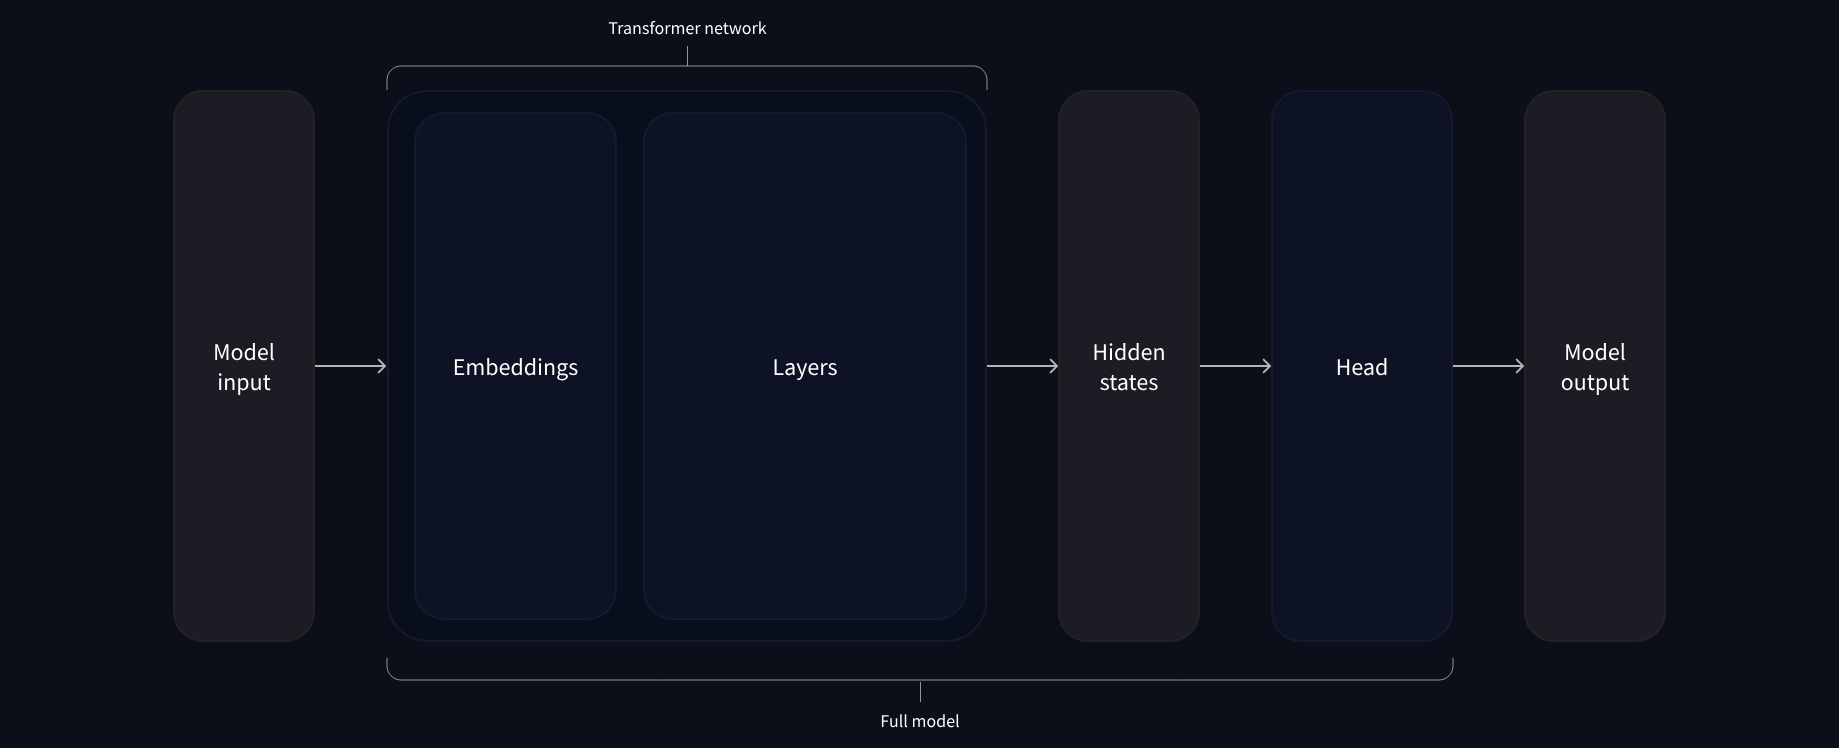

There are many different architectures available in 🤗 Transformers, with each one designed around tackling a specific task.

For our example, we will need a model with a sequence classification head (to be able to classify the sentences as positive or negative). So, we won’t actually use the `AutoModel` class, but `AutoModelForSequenceClassification`:

In [7]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13232.05it/s]


Now if we look at the shape of our outputs, the dimensionality will be much lower: the model head takes as input the high-dimensional vectors we saw before, and outputs vectors containing two values (one per label):

In [8]:
print(outputs.logits.shape)

torch.Size([2, 2])


Since we have just two sentences and two labels, the result we get from our model is of shape 2 x 2.

### Postprocessing the output :-

The values we get as output from our model don’t necessarily make sense by themselves. Let’s take a look:

In [9]:
print(outputs.logits)

tensor([[-1.5607,  1.6123],
        [ 4.1692, -3.3464]], grad_fn=<AddmmBackward0>)


Our model predicted `[-1.5607, 1.6123]` for the first sentence and `[ 4.1692, -3.3464]` for the second one. Those are not probabilities but `logits`, the raw, unnormalized scores outputted by the last layer of the model. To be converted to probabilities, they need to go through a **SoftMax** layer.

**In practice, when training:**

* Applying softmax first, then calculating cross entropy loss separately = **less numerically stable + slower**

* Modern frameworks (PyTorch included) have combined functions like `CrossEntropyLoss` that take **raw logits directly and do softmax + loss calculation in one step = more stable + faster**

So models output raw logits because the training loss function expects raw logits, not probabilities. Softmax gets applied internally inside the loss function during training.

At **inference time** (when you're just using the model, not training) you apply softmax yourself to convert logits to probabilities. Which is exactly what `pipeline()` does for you automatically in the postprocessing step.

In [10]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[4.0195e-02, 9.5980e-01],
        [9.9946e-01, 5.4418e-04]], grad_fn=<SoftmaxBackward0>)


Now we can see that the model predicted `[0.0402, 0.9598]` for the first sentence and ``[0.9995, 0.0005] for the second one. These are recognizable probability scores.

To get the labels corresponding to each position, we can inspect the `id2label` attribute of the model config (more on this in the next section)

In [11]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

Now we can conclude that the model predicted the following:

* First sentence: NEGATIVE: 0.0402, POSITIVE: 0.9598

* Second sentence: NEGATIVE: 0.9995, POSITIVE: 0.0005

We have successfully reproduced the three steps of the pipeline: preprocessing with tokenizers, passing the inputs through the model, and postprocessing! Now let’s take some time to dive deeper into each of those steps.

# Models 

we’ll take a closer look at creating and using models. We’ll use the `AutoModel` class, which is handy when you want to instantiate any model from a checkpoint.

#### Creating a Transformer :-

Let’s begin by examining what happens when we instantiate an `AutoModel`:

In [1]:
from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-cased")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--bert-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an admini

Similar to the tokenizer, the `from_pretrained()` method will download and cache the model data from the Hugging Face Hub. As mentioned previously, the checkpoint name corresponds to a specific model architecture and weights, in this case a BERT model with a basic architecture (12 layers, 768 hidden size, 12 attention heads) and cased inputs (meaning that the uppercase/lowercase distinction is important). There are many checkpoints available on the Hub.

The `AutoModel` class and its associates are actually simple wrappers designed to fetch the appropriate model architecture for a given checkpoint. It’s an “auto” class meaning it will guess the appropriate model architecture for you and instantiate the correct model class. However, if you know the type of model you want to use, you can use the class that defines its architecture directly:

In [1]:
from transformers import BertModel

model = BertModel.from_pretrained("bert-base-cased")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8413.72it/s]
[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignore

#### Loading and saving :-

Saving a model is as simple as saving a tokenizer. In fact, the models actually have the same `save_pretrained()` method, which saves the model’s weights and architecture configuration:

In [2]:
model.save_pretrained("directory_on_my_computer")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


This will save two files to your disk:

In [5]:
ls directory_on_my_computer

 Volume in drive C is Windows-SSD
 Volume Serial Number is D840-26F5

 Directory of c:\Techs\AI ML\PyTorch\NLP\2-Using HuggingFace Transformers\directory_on_my_computer

12-06-2026  20:23    <DIR>          .
12-06-2026  20:23    <DIR>          ..
12-06-2026  20:23               776 config.json
12-06-2026  20:23       433,263,424 model.safetensors
               2 File(s)    433,264,200 bytes
               2 Dir(s)  254,161,858,560 bytes free


If you look inside the `config.json` file, you’ll see all the necessary attributes needed to build the model architecture. This file also contains some metadata, such as where the checkpoint originated and what 🤗 Transformers version you were using when you last saved the checkpoint.

The `pytorch_model.safetensors` file is known as the state dictionary; it contains all your model’s weights. The two files work together: the configuration file is needed to know about the model architecture, while the model weights are the parameters of the model.

To reuse a saved model, use the `from_pretrained()` method again:

In [6]:
from transformers import AutoModel

model = AutoModel.from_pretrained("directory_on_my_computer")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13332.05it/s]


A wonderful feature of the 🤗 Transformers library is the ability to easily share models and tokenizers with the community. To do this, make sure you have an account on Hugging Face. If you’re using a notebook, you can easily log in with this:

### Encoding Text :-

Transformer models handle text by turning the inputs into numbers. Here we will look at exactly what happens when your text is processed by the tokenizer. We’ve already seen in Chapter 1 that tokenizers split the text into tokens and then convert these tokens into numbers. We can see this conversion through a simple tokenizer:

In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

encoded_input = tokenizer("Hello, I'm a single sentence!")
print(encoded_input)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'input_ids': [101, 8667, 117, 146, 112, 182, 170, 1423, 5650, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


We get a dictionary with the following fields:

* input_ids: numerical representations of your tokens

* token_type_ids: these tell the model which part of the input is sentence A and which is sentence B (discussed more in the next section)

* attention_mask: this indicates which tokens should be attended to and which should not (discussed more in a bit)

We can decode the input IDs to get back the original text:

In [2]:
tokenizer.decode(encoded_input['input_ids'])

"[CLS] Hello, I ' m a single sentence! [SEP]"

You’ll notice that the tokenizer has added special tokens — `[CLS]` and `[SEP]` — required by the model. Not all models need special tokens; they’re utilized when a model was pretrained with them, in which case the tokenizer needs to add them as that model expects these tokens.

You can encode multiple sentences at once, either by batching them together (we’ll discuss this soon) or by passing a list:

In [3]:
encoded_input = tokenizer("How are you?", "I'm fine, thank you!")
print(encoded_input)

{'input_ids': [101, 1731, 1132, 1128, 136, 102, 146, 112, 182, 2503, 117, 6243, 1128, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [4]:
tokenizer.decode(encoded_input['input_ids'])

"[CLS] How are you? [SEP] I ' m fine, thank you! [SEP]"

Note that when passing multiple sentences, the tokenizer returns a list for each sentence for each dictionary value. We can also ask the tokenizer to return tensors directly from PyTorch:

In [5]:
encoded_input = tokenizer("How are you?", "I'm fine, thank you!", return_tensors="pt")
print(encoded_input)

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  136,  102,  146,  112,  182, 2503,  117, 6243,
         1128,  106,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


By default `tokenizer()` returns plain Python lists.

But models expect **PyTorch tensors**, not plain lists. So instead of manually converting with `torch.tensor()` yourself, you can just tell the tokenizer to return tensors directly, and it gives you PyTorch tensors straight away, ready to feed into the model

But there’s a problem: the two lists don’t have the same length! Arrays and tensors need to be rectangular, so we can’t simply convert these lists to a PyTorch tensor (or NumPy array). The tokenizer provides an option for that: padding.

The 2 lists should have the same length because of how matrix operations work inside the model — it processes all sentences **simultaneously as one big tensor**, and tensors must be rectangular (same shape).

**Padding** fixes this by adding special `[PAD]` tokens to the shorter sentence to match the longer one:

### Padding inputs :-

If we ask the tokenizer to pad the inputs, it will make all sentences the same length by adding a special padding token to the sentences that are shorter than the longest one:

In [6]:
encoded_input = tokenizer(
    ["How are you?", "I'm fine, thank you!"], padding=True, return_tensors="pt"
)
print(encoded_input)

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  136,  102,    0,    0,    0,    0],
        [ 101,  146,  112,  182, 2503,  117, 6243, 1128,  106,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Now we have rectangular tensors! Note that the padding tokens have been encoded into input IDs with ID 0, and they have an attention mask value of 0 as well. This is because those padding tokens shouldn’t be analyzed by the model: they’re not part of the actual sentence.

### Truncating(to make something shorter) inputs :-

The tensors might get too big to be processed by the model. For instance, BERT was only pretrained with sequences up to 512 tokens, so it cannot process longer sequences.

Meaning as the input we give to the model gets tokenized so after tokenization the maximum token number that the BERT can handle is 512 tokens so if our input is too long then there will be lot of tokens and if exceeded 512 tokens then the BERT model can produce garbage output.

 If you have sequences longer than the model can handle, you’ll need to truncate them with the `truncation` parameter:

In [ ]:
encoded_input = tokenizer(
    "very " * 600,   # 600 repetitions of "very"
    truncation=True,
)
print(encoded_input)
print("----------------------------------------------------------------------------------------------")
print(encoded_input["input_ids"])

{'input_ids': [101, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 13

Noticed number of tokens are less than 512 while "very" word had 600 repetitions!

By combining the padding and truncation arguments, you can make sure your tensors have the exact size you need:

In [ ]:
encoded_input = tokenizer(
    ["How are you?", "I'm fine, thank you!"],
    padding=True,
    truncation=True,
    max_length=5,    # means truncate anything longer than 5 tokens (Basically here we set the limit model can handle the input tokens). Sentence with 5 tokens → stays 5
    return_tensors="pt",
)
print(encoded_input)

{'input_ids': tensor([[ 101, 1731, 1132, 1128,  102],
        [ 101,  146,  112,  182,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]])}


### Adding special tokens :-

Special tokens (or at least the concept of them) is particularly important to BERT and derived models. These tokens are added to better represent the sentence boundaries, such as the beginning of a sentence `([CLS])` or separator between sentences `([SEP])`. Let’s look at a simple example:

In [16]:
encoded_input = tokenizer("How are you?")
print(encoded_input['input_ids'])
tokenizer.decode(encoded_input['input_ids'])

[101, 1731, 1132, 1128, 136, 102]


'[CLS] How are you? [SEP]'

These special tokens are automatically added by the tokenizer. Not all models need special tokens; they are primarily used when a model was pretrained with them, in which case the tokenizer will add them since the model expects them.

While the model accepts a lot of different arguments, only the input IDs are necessary. We’ll explain what the other arguments do and when they are required later, but first we need to take a closer look at the tokenizers that build the inputs that a Transformer model can understand.

# Tokenizers :-

Tokenizers are one of the core components of the NLP pipeline. They serve one purpose: to translate text into data that can be processed by the model. Models can only process numbers, so tokenizers need to convert our text inputs to numerical data and these numbers are not just numbers but they provide numerical representation of the input so the model can understand and learn. In this section, we’ll explore exactly what happens in the tokenization pipeline.

In NLP tasks, the data that is generally processed is raw text. Here’s an example of such text:

> Jim Henson was a puppeteer 

However, models can only process numbers, so we need to find a way to convert the raw text to numbers. That’s what the tokenizers do, and there are a lot of ways to go about this. The goal is to find the most meaningful representation — that is, the one that makes the most sense to the model — and, if possible, the smallest representation.

Let’s take a look at some examples of tokenization algorithms, and try to answer some of the questions you may have about tokenization.

### Word-based :-

The first type of tokenizer that comes to mind is `word-based`. It’s generally very easy to set up and use with only a few rules, and it often yields decent results. For example, in the image below, the goal is to split the raw text into words and find a numerical representation for each of them:

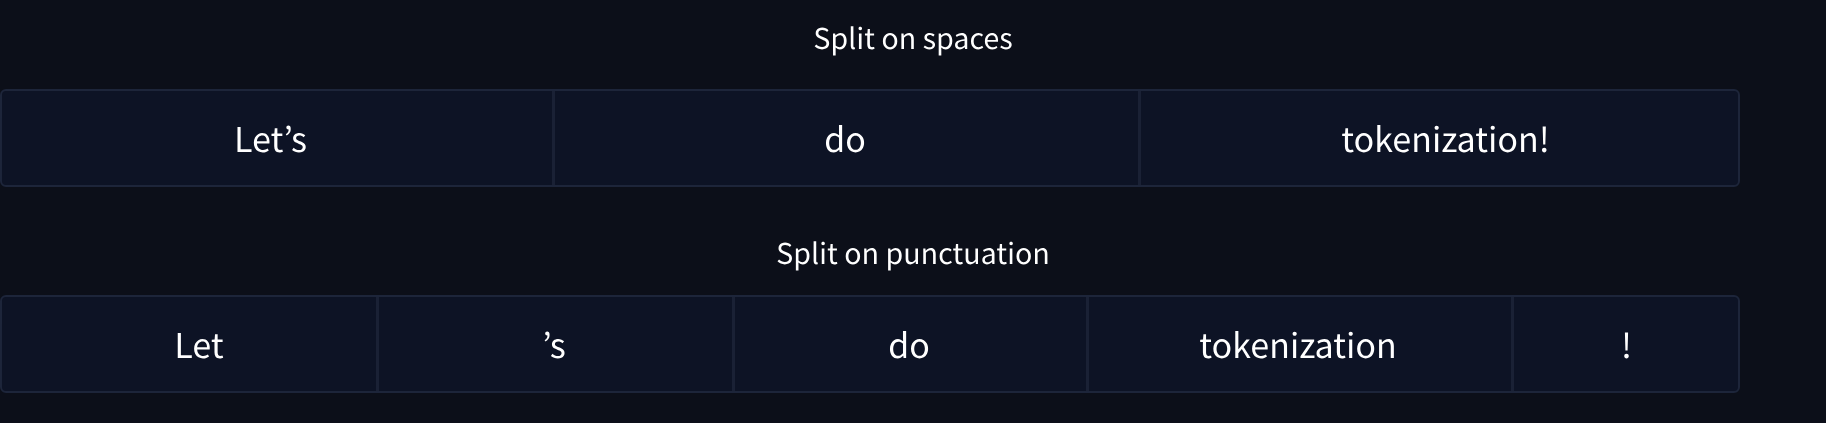

There are different ways to split the text. For example, we could use whitespace to tokenize the text into words by applying Python’s `split()` function:

In [1]:
tokenized_text = "Jim Henson was a puppeteer".split()
print(tokenized_text)

['Jim', 'Henson', 'was', 'a', 'puppeteer']


There are also variations of word tokenizers that have extra rules for punctuation. With this kind of tokenizer, we can end up with some pretty large “vocabularies,” where a vocabulary is defined by the total number of independent tokens that we have in our corpus.

Each word gets assigned an ID, starting from 0 and going up to the size of the vocabulary. The model uses these IDs to identify each word.

If we want to completely cover a language with a word-based tokenizer, we’ll need to have an identifier for each word in the language, which will generate a huge amount of tokens. For example, there are over 500,000 words in the English language, so to build a map from each word to an input ID we’d need to keep track of that many IDs. Furthermore, words like “dog” are represented differently from words like “dogs”, and the model will initially have no way of knowing that “dog” and “dogs” are similar: it will identify the two words as unrelated. The same applies to other similar words, like “run” and “running”, which the model will not see as being similar initially.

Finally, we need a custom token to represent words that are not in our vocabulary. This is known as the “unknown” token, often represented as `"[UNK]"` or `"<unk>"`. It’s generally a bad sign if you see that the tokenizer is producing a lot of these tokens, as it wasn’t able to retrieve a sensible representation of a word and you’re losing information along the way. The goal when crafting the vocabulary is to do it in such a way that the tokenizer tokenizes as few words as possible into the unknown token.

One way to reduce the amount of unknown tokens is to go one level deeper, using a character-based tokenizer.

### Character-based :-

`Character-based` tokenizers split the text into characters, rather than words. This has two primary benefits:

* The vocabulary is much smaller. The vocabulary only needs 26 letters + punctuation + numbers → maybe 200-300 unique characters

* There are much fewer out-of-vocabulary (unknown) tokens, since every word can be built from characters.

So `character-based` has way more tokens per sentence but a much `smaller vocabulary`.

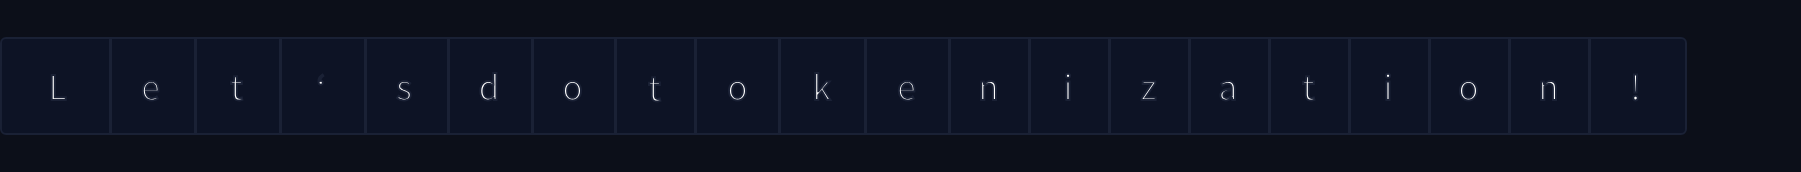

This approach isn’t perfect either. Since the representation is now based on characters rather than words, one could argue that, intuitively, it’s less meaningful: each character doesn’t mean a lot on its own, whereas that is the case with words. However, this again differs according to the language; in Chinese, for example, each character carries more information than a character in a Latin language.

Another thing to consider is that we’ll end up with a very large amount of tokens to be processed by our model: whereas a word would only be a single token with a word-based tokenizer, it can easily turn into 10 or more tokens when 
converted into characters.

To get the best of both worlds, we can use a third technique that combines the two approaches: `subword tokenization`.

### Subword tokenization :-

Subword tokenization algorithms rely on the principle that frequently used words should not be split into smaller subwords, but rare words should be decomposed into meaningful subwords.

For instance, “annoyingly” might be considered a rare word and could be decomposed into “annoying” and “ly”. These are both likely to appear more frequently as standalone subwords, while at the same time the meaning of “annoyingly” is kept by the composite meaning of “annoying” and “ly”.

Here is an example showing how a subword tokenization algorithm would tokenize the sequence “Let’s do tokenization!“:

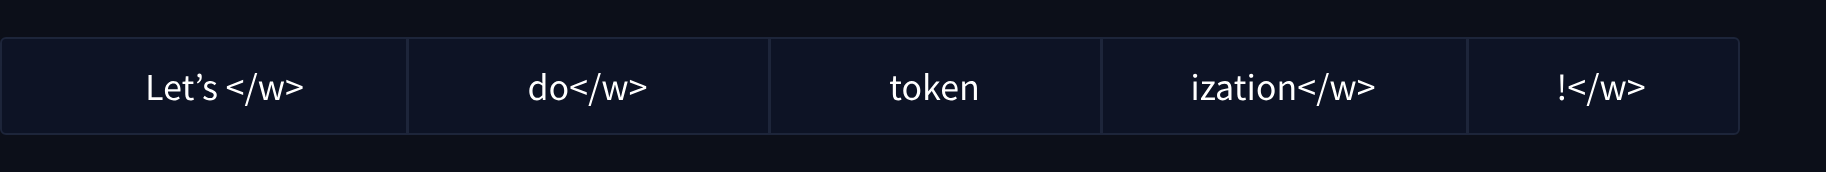

These subwords end up providing a lot of semantic meaning: for instance, in the example above “tokenization” was split into “token” and “ization”, two tokens that have a semantic meaning while being space-efficient (only two tokens are needed to represent a long word). This allows us to have relatively good coverage with small vocabularies, and close to no unknown tokens.

This approach is especially useful in agglutinative languages such as Turkish, where you can form (almost) arbitrarily long complex words by stringing together subwords.

**And more!**

Unsurprisingly, there are many more techniques out there. To name a few:

* Byte-level BPE, as used in GPT-2

* WordPiece, as used in BERT

* SentencePiece or Unigram, as used in several multilingual models

You should now have sufficient knowledge of how tokenizers work to get started with the API.

### Loading and saving :-

Loading and saving tokenizers is as simple as it is with models. Actually, it’s based on the same two methods: `from_pretrained()` and `save_pretrained()`. These methods will load or save the algorithm used by the tokenizer (a bit like the architecture of the model) as well as its vocabulary (a bit like the weights of the model).

Loading the BERT tokenizer trained with the same checkpoint as BERT is done the same way as loading the model, except we use the `BertTokenizer` class:

In [2]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Similar to `AutoModel`, the `AutoTokenizer` class will grab the proper tokenizer class in the library based on the checkpoint name, and can be used directly with any checkpoint:

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [4]:
tokenizer("Using a Transformer network is simple")

{'input_ids': [101, 7993, 170, 13809, 23763, 2443, 1110, 3014, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

Saving a tokenizer is identical to saving a model:

In [5]:
tokenizer.save_pretrained("directory_on_my_computer")

('directory_on_my_computer\\tokenizer_config.json',
 'directory_on_my_computer\\tokenizer.json')

We’ll talk more about `token_type_ids` in Chapter 3, and we’ll explain the `attention_mask` key a little later. First, let’s see how the `input_id`s are generated. To do this, we’ll need to look at the intermediate methods of the tokenizer.

### Encoding :-

Translating text to numbers is known as encoding. Encoding is done in a two-step process: the tokenization, followed by the conversion to input IDs.

As we’ve seen, the first step is to split the text into words (or parts of words, punctuation symbols, etc.), usually called `tokens`. There are multiple rules that can govern that process, which is why we need to instantiate the tokenizer using the name of the model, to make sure we use the same rules that were used when the model was pretrained.

The second step is to convert those tokens into numbers, so we can build a tensor out of them and feed them to the model. To do this, the tokenizer has a `vocabulary`, which is the part we download when we instantiate it with the `from_pretrained()` method. Again, we need to use the same vocabulary used when the model was pretrained.

To get a better understanding of the two steps, we’ll explore them separately. Note that we will use some methods that perform parts of the tokenization pipeline separately to show you the intermediate results of those steps, but in practice, you should call the tokenizer directly on your inputs.

#### Tokenization:

The tokenization process is done by the `tokenize()` method of the tokenizer:

In [26]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

sequence = "Using a Transformer network is simple"
tokens = tokenizer.tokenize(sequence)

print(tokens)

['Using', 'a', 'Trans', '##former', 'network', 'is', 'simple']


The output of this method is a list of strings, or tokens.

This tokenizer is a **subword tokenizer**: it splits the words until it obtains tokens that can be represented by its vocabulary. That’s the case here with *transformer*, which is split into two tokens: `Trans` and `##former`.

#### From tokens to input IDs :-

The conversion to input IDs is handled by the `convert_tokens_to_ids()` tokenizer method:

In [27]:
input_ids = tokenizer.convert_tokens_to_ids(tokens)
print(input_ids)

[7993, 170, 13809, 23763, 2443, 1110, 3014]


These outputs, once converted to the appropriate framework tensor, can then be used as inputs to a model as seen earlier in this chapter.

> `✏️ Try it out!` Replicate the two last steps (tokenization and conversion to input IDs) on the input sentences we used in section 2: "I hate this so much!"). Check that you get the same input IDs we got earlier!

In [28]:
tokens = tokenizer.tokenize("I hate this so much!")

input_ids = tokenizer.convert_tokens_to_ids(tokens)
print(input_ids)

[146, 4819, 1142, 1177, 1277, 106]


In [29]:
from transformers import AutoTokenizer

checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

raw_inputs = "I hate this so much!"

inputs = tokenizer(raw_inputs)
print(inputs)

{'input_ids': [101, 146, 4819, 1142, 1177, 1277, 106, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


**Noticed there's 2 extra tokens in start and end i.e 101 & 102 when used tokenizer() method?**

Those two extra tokens are special tokens that `tokenizer()` adds automatically but `tokenize() + convert_tokens_to_ids()` does NOT add:

* `101` → `[CLS]` token — added at the start of every sequence
* `102` → `[SEP]` token — added at the end of every sequence

**What are they?**

* `[CLS]` → stands for classification. BERT uses this token's final hidden state as the overall representation of the entire sentence for classification tasks

* `[SEP]` → stands for separator. Tells the model where a sentence ends, useful when you have two sentences as input

### Decoding :-

Decoding is going the other way around: from vocabulary indices, we want to get a string. This can be done with the `decode()` method as follows:

In [34]:
decoded_string = tokenizer.decode([7993, 170, 11303, 1200, 2443, 1110, 3014])
print(decoded_string)

decoded_string = tokenizer.decode([146, 4819, 1142, 1177, 1277, 106])
print(decoded_string)

decoded_string = tokenizer.decode([101, 146, 4819, 1142, 1177, 1277, 106, 102])
print(decoded_string)

Using a transformer network is simple
I hate this so much!
[CLS] I hate this so much! [SEP]


Note that the decode method not only converts the indices back to tokens, but also groups together the tokens(talking about "transformer") that were part of the same words to produce a readable sentence. This behavior will be extremely useful when we use models that predict new text (either text generated from a prompt, or for sequence-to-sequence problems like translation or summarization).

# Handling multiple sequences :-

 we explored the simplest of use cases: doing inference on a single sequence of a small length. However,some questions emerge already:

* How do we handle multiple sequences?

* How do we handle multiple sequences of different lengths?

* Are vocabulary indices the only inputs that allow a model to work well?

* Is there such a thing as too long a sequence?

Let’s see what kinds of problems these questions pose, and how we can solve them using the 🤗 Transformers API.

### Models expect a batch of inputs :-

In the previous exercise you saw how sequences get translated into lists of numbers. Let’s convert this list of numbers to a tensor and send it to the model:

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor(ids)

print(input_ids)

output = model(input_ids)
print(output)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6005.80it/s]

tensor([ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
         2026,  2878,  2166,  1012])


RuntimeError: The size of tensor a (14) must match the size of tensor b (512) at non-singleton dimension 1

Error because the problem is that we sent a single sequence to the model, whereas 🤗 Transformers models expect multiple sentences by default. Here we tried to do everything the tokenizer did behind the scenes when we applied it to a `sequence`. But if you look closely, you’ll see that the tokenizer didn’t just convert the list of input IDs into a tensor, it added a dimension on top of it:

In [6]:
tokenized_inputs = tokenizer(sequence, return_tensors="pt")
print(tokenized_inputs["input_ids"])

tensor([[  101,  1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,
          2607,  2026,  2878,  2166,  1012,   102]])


Let’s try again and add a new dimension:

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence = "I've been waiting for a HuggingFace course my whole life."

tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)

input_ids = torch.tensor([ids])
print("Input IDs:", input_ids)

output = model(input_ids)
print("Logits:", output.logits)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8238.73it/s]

Input IDs: tensor([[ 1045,  1005,  2310,  2042,  3403,  2005,  1037, 17662, 12172,  2607,
          2026,  2878,  2166,  1012]])
Logits: tensor([[-2.7276,  2.8789]], grad_fn=<AddmmBackward0>)


`Batching` is the act of sending multiple sentences through the model, all at once. If you only have one sentence, you can just build a batch with a single sequence:

In [15]:
batched_ids = [ids, ids]

print(batched_ids)

[[1045, 1005, 2310, 2042, 3403, 2005, 1037, 17662, 12172, 2607, 2026, 2878, 2166, 1012], [1045, 1005, 2310, 2042, 3403, 2005, 1037, 17662, 12172, 2607, 2026, 2878, 2166, 1012]]


This is a batch of two identical sequences!

`Batching` allows the model to work when you feed it multiple sentences. Using multiple sequences is just as simple as building a batch with a single sequence. There’s a second issue, though. When you’re trying to batch together two (or more) sentences, they might be of different lengths, we know that they need to be of rectangular shape, so we won’t be able to convert the list of input IDs into a tensor directly. To work around this problem, we usually `pad` the inputs.

#### Padding the inputs :-

The following list of lists cannot be converted to a tensor:

In [16]:
batched_ids = [
    [200, 200, 200],
    [200, 200]
]

In order to work around this, we’ll use `padding` to make our tensors have a rectangular shape. Padding makes sure all our sentences have the same length by adding a special word called the `padding token` to the sentences with fewer values. For example, if you have 10 sentences with 10 words and 1 sentence with 20 words, padding will ensure all the sentences have 20 words. In our example, the resulting tensor looks like this:

In [17]:
padding_id = 100

batched_ids = [
    [200, 200, 200],
    [200, 200, padding_id],
]

The padding token ID can be found in `tokenizer.pad_token_id`. Let’s use it and send our two sentences through the model individually and batched together:

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence1_ids = [[200, 200, 200]]
sequence2_ids = [[200, 200]]

batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

print(model(torch.tensor(sequence1_ids)).logits)
print(model(torch.tensor(sequence2_ids)).logits)
print(model(torch.tensor(batched_ids)).logits)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 15242.42it/s]

tensor([[ 1.5694, -1.3895]], grad_fn=<AddmmBackward0>)
tensor([[ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)
tensor([[ 1.5694, -1.3895],
        [ 1.3374, -1.2163]], grad_fn=<AddmmBackward0>)


There’s something wrong with the logits in our batched predictions: the second row should be the same as the logits for the second sentence, but we’ve got completely different values!

This is because the key feature of Transformer models is `attention layers` that `contextualize` each token. These will take into account the padding tokens since they attend to all of the tokens of a sequence. To get the same result when passing individual sentences of different lengths through the model or when passing a batch with the same sentences and padding applied, we need to tell those attention layers to ignore the padding tokens. This is done by using an attention mask.

### Attention masks :-

`Attention masks` are tensors with the exact same shape as the input IDs tensor, filled with `0s` and `1s`: `1s` indicate the corresponding tokens **should be attended** to, and `0s` indicate the corresponding tokens **should not be attended** to (i.e., they should be ignored by the attention layers of the model).

Let’s complete the previous example with an attention mask:

In [24]:
batched_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id],
]

attention_mask = [
    [1, 1, 1],
    [1, 1, 0],
]

outputs = model(torch.tensor(batched_ids), attention_mask=torch.tensor(attention_mask))
print(outputs.logits)

tensor([[ 1.5694, -1.3895],
        [ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)


Now we get the same logits for the second sentence in the batch.

Notice how the last value of the second sequence is a padding ID, which is a 0 value in the attention mask.

### Longer sequences :-

With Transformer models, there is a limit to the lengths of the sequences we can pass the models. Most models handle sequences of up to `512` or `1024` tokens, and will crash when asked to process longer sequences. There are two solutions to this problem:

* Use a model with a longer supported sequence length.

* Truncate your sequences.

Models have different supported sequence lengths, and some specialize in handling very long sequences. `Longformer` is one example, and another is `LED`. If you’re working on a task that requires very long sequences, we recommend you take a look at those models.

Otherwise, we recommend you truncate your sequences by specifying the `max_sequence_length` parameter:

> sequence = sequence[:max_sequence_length]

### Padding according to several objectives :-

In [40]:
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

# Will pad the sequences up to the maximum sequence length
model_inputs = tokenizer(sequences, padding="longest")

# Will pad the sequences up to the model max length
# (512 for BERT or DistilBERT)
model_inputs = tokenizer(sequences, padding="max_length")

# Will pad the sequences up to the specified max length
model_inputs = tokenizer(sequences, padding="max_length", max_length=8)

It can also truncate sequences:

In [41]:
# Will truncate the sequences that are longer than the model max length
# (512 for BERT or DistilBERT)
model_inputs = tokenizer(sequences, truncation=True)

# Will truncate the sequences that are longer than the specified max length
model_inputs = tokenizer(sequences, max_length=8, truncation=True)

In [43]:
sequences = ["I've been waiting for a HuggingFace course my whole life.", "So have I!"]

# we are prompting the tokenizer to return tensors from the different frameworks — "pt" returns PyTorch tensors and "np" returns NumPy arrays:

# Returns PyTorch tensors
model_inputs = tokenizer(sequences, padding=True, return_tensors="pt")

# Returns NumPy arrays
model_inputs = tokenizer(sequences, padding=True, return_tensors="np")

> **✏️ Try it out!** Apply the tokenization manually on the two sentences: “I’ve been waiting for a HuggingFace course my whole life.” and “I hate this so much!”). Pass them through the model,batch them together using the padding token, then create the proper attention mask. Check the results when going through the model!

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

sequence1 = "I've been waiting for a HuggingFace course my whole life"
sequence2 = "I hate this so much!"

encoded_input = tokenizer(
    [sequence1, sequence2], padding=True, return_tensors="pt"
)

output = model(encoded_input['input_ids'], attention_mask=encoded_input['attention_mask'])
print(output.logits)

# Or even cleaner, just unpack the whole thing at once:
output = model(**encoded_input)
print(output.logits)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1241.00it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint

tensor([[ 0.2960, -0.9869],
        [ 0.3693, -0.9310]], grad_fn=<AddmmBackward0>)
tensor([[ 0.2960, -0.9869],
        [ 0.3693, -0.9310]], grad_fn=<AddmmBackward0>)
